# Notebook 2 — LUNA16 Fine-tune Dataset Class

**Amaç:** Notebook 1'in `nodules.csv` ve `nodule_masks.h5` çıktılarını + ham `candidates.csv` negatif havuzunu kullanarak 3-task multi-label LUNA16 Dataset'i kur, sanity check yap.

**Pipeline ana özellikleri:**
- Patch size: **64×64×64** (MAE encoder ile uyumlu, ViT-L 16³ patch → 4³=64 token)
- HU normalization: `clip(-1000, +1000) → [0, 1]` (pretrain ile birebir aynı)
- World↔voxel dönüşümü: NPZ origin/spacing scan-spesifik (resampling yok)
- Negatif sampling: 1:3 pozitif:negatif (Gemini'ın stratejisi), split-restricted
- Augmentation: flip 3 eksen + rot90 axial plane + mild Gaussian noise
- Multi-task labels: detection (bin) / malignancy (bin, ignore=-1) / segmentation (bool mask + seg_loss_mask)

**Girdiler:**
- `nodules.csv` (Notebook 1)
- `nodule_masks.h5` (Notebook 1)
- `candidates.csv` (orijinal LUNA16)
- LUNA16 NPZ dosyaları

**Çıktılar:**
- `train_samples.csv`, `val_samples.csv`, `test_samples.csv` (Drive'a kaydedilir)
- `LUNA16NoduleDataset` class (training notebook'a import edilir)
- Sanity check görselleştirmeleri


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, h5py, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA: True


## 2. Yollar ve parametreler

In [2]:
# === GİRDİLER ===
NODULES_CSV    = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodules.csv'
MASKS_H5       = '/content/drive/MyDrive/bitirme/Finetune_Labels/nodule_masks.h5'
CANDIDATES_CSV = '/content/drive/MyDrive/bitirme/Dataset/candidates.csv'
NPZ_DIR        = '/content/drive/MyDrive/bitirme/LUNA_Processed'

# === ÇIKTILAR ===
SPLITS_DIR     = '/content/drive/MyDrive/bitirme/Finetune_Labels/splits'
TRAIN_CSV      = os.path.join(SPLITS_DIR, 'train_samples.csv')
VAL_CSV        = os.path.join(SPLITS_DIR, 'val_samples.csv')
TEST_CSV       = os.path.join(SPLITS_DIR, 'test_samples.csv')
SPLIT_META     = os.path.join(SPLITS_DIR, 'split_meta.json')

os.makedirs(SPLITS_DIR, exist_ok=True)

# === PARAMETRELER ===
PATCH_SIZE = (64, 64, 64)        # ViT-L MAE pretrain ile aynı
NEGATIVE_RATIO = 3               # 1 pozitif : 3 negatif
HU_CLIP = (-1000, 1000)          # PRETRAIN ile birebir aynı
JITTER_VOXELS = 8                # ±8 voxel jitter pozitif patch'lerde
RANDOM_SEED = 42

# Split oranları (seriesuid level)
TRAIN_FRAC = 0.8
VAL_FRAC   = 0.1
TEST_FRAC  = 0.1

np.random.seed(RANDOM_SEED)
print('Konfigürasyon OK')

Konfigürasyon OK


## 3. Notebook 1 çıktılarını yükle

In [3]:
nodules_df = pd.read_csv(NODULES_CSV)
print(f'nodules.csv: {len(nodules_df)} satır')
print(f'  Benign  (label=0): {(nodules_df["malignancy_label"]==0).sum()}')
print(f'  Malign  (label=1): {(nodules_df["malignancy_label"]==1).sum()}')
print(f'  Ambig.  (NaN):     {nodules_df["malignancy_label"].isna().sum()}')
print(f'  Mask başarılı:     {nodules_df["has_mask"].sum()}')

candidates_df = pd.read_csv(CANDIDATES_CSV)
print(f'\ncandidates.csv: {len(candidates_df):,} satır')
print(f'  class=0 (negative): {(candidates_df["class"]==0).sum():,}')

# H5'i smoke test et
with h5py.File(MASKS_H5, 'r') as h5f:
    print(f'\nmasks.h5: {len(h5f.keys())} nodule mask')
    sample_key = list(h5f.keys())[0]
    grp = h5f[sample_key]
    print(f'  Sample: {sample_key}')
    print(f'  Mask shape: {grp["mask"].shape}')
    print(f'  Bbox attrs: z={grp.attrs["z_start"]}:{grp.attrs["z_stop"]}, '
          f'y={grp.attrs["y_start"]}:{grp.attrs["y_stop"]}, '
          f'x={grp.attrs["x_start"]}:{grp.attrs["x_stop"]}')

nodules.csv: 1100 satır
  Benign  (label=0): 327
  Malign  (label=1): 313
  Ambig.  (NaN):     460
  Mask başarılı:     1094

candidates.csv: 551,065 satır
  class=0 (negative): 549,714

masks.h5: 1094 nodule mask
  Sample: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860_nod0
  Mask shape: (4, 12, 13)
  Bbox attrs: z=76:80, y=206:218, x=39:52


## 4. NPZ dosyalarını keşfet

NPZ isim varyasyonunu çöz (nokta veya alt-tire), her seriesuid için path map kur.

In [4]:
print('NPZ dosyaları taranıyor...')
npz_files = list(Path(NPZ_DIR).glob('*.npz'))
print(f'  Bulunan NPZ: {len(npz_files)}')

# seriesuid → npz path map
# NPZ isimleri ya tam seriesuid, ya da noktalar alt-tire ile değiştirilmiş hâli
npz_path_map = {}
for p in npz_files:
    stem = p.stem
    # Olduğu gibi
    npz_path_map[stem] = p
    # Alt-tire → nokta varyantı (seriesuid kanonik formuna eşle)
    if '_' in stem and '.' not in stem:
        canonical = stem.replace('_', '.', 5)  # ilk 5 alt-tire nokta
        # LUNA16 seriesuid format: 1.3.6.1.4.1.14519.5.2.1.6279.6001.<hash>
        # 11 nokta var (12 segment). Ama _ → . dönüşümü heuristik. Daha güvenli yol:
        # tüm alt-tireleri noktayla değiştir.
        canonical = stem.replace('_', '.')
        npz_path_map[canonical] = p

print(f'  Map girişi: {len(npz_path_map)}')

# nodules.csv'deki seriesuid'lerden kaçı NPZ map'inde var?
found = nodules_df['seriesuid'].isin(npz_path_map).sum()
print(f'  nodules.csv\'de NPZ bulunan: {found}/{len(nodules_df)}')

if found < len(nodules_df) * 0.95:
    # NPZ isim varyasyonu farklı olabilir, örnek göster
    missing = nodules_df[~nodules_df['seriesuid'].isin(npz_path_map)]['seriesuid'].head(3)
    print(f'\n  ⚠️ Eksik örnek seriesuid:')
    for s in missing: print(f'    {s}')
    print(f'\n  NPZ dosya örnekleri:')
    for p in npz_files[:3]: print(f'    {p.name}')

NPZ dosyaları taranıyor...
  Bulunan NPZ: 888
  Map girişi: 888
  nodules.csv'de NPZ bulunan: 1100/1100


## 5. Negatif havuzu hazırla

`candidates.csv` class=0 → sample edilebilecek negatif candidate'lar. Hepsini training'e dahil etmiyoruz (Gemini'ın stratejisi), sadece pozitif sayısının 3 katı kadar sample edeceğiz. Ama önce **tüm class=0'ı havuz olarak tut**, split sırasında ve runtime'da örnekleme yap.

In [5]:
# Negatif havuzu
neg_pool = candidates_df[candidates_df['class'] == 0].copy()
neg_pool['is_nodule'] = 0
print(f'Negatif havuz boyutu: {len(neg_pool):,}')

# Pozitifler: nodules.csv ana kaynak
pos_pool = nodules_df.copy()
pos_pool['is_nodule'] = 1
# class kolonu yoksa ekle (geçiş kolaylığı için)
print(f'Pozitif havuz boyutu: {len(pos_pool):,}')

# 1:3 oranıyla kaç negatif lazım?
n_neg_needed = len(pos_pool) * NEGATIVE_RATIO
print(f'\n1:{NEGATIVE_RATIO} oranı için lazım negatif: {n_neg_needed}')
print(f'  Havuzda yeterli negatif: {"EVET" if len(neg_pool) >= n_neg_needed else "HAYIR"}')

Negatif havuz boyutu: 549,714
Pozitif havuz boyutu: 1,100

1:3 oranı için lazım negatif: 3300
  Havuzda yeterli negatif: EVET


## 6. Patient-level train/val/test split

seriesuid bazında bölüyoruz ki **aynı hastanın patch'i** train ve val'da olmasın (data leakage). 888 scan → 80/10/10 = 710/89/89.

In [6]:
# Tüm pozitif scan'leri al (en azından bir nodülü olan)
all_pos_scans = set(pos_pool['seriesuid'].unique())
# Negatif-only scan'leri de dahil et (nodul içermeyen 298 scan)
all_neg_scans = set(neg_pool['seriesuid'].unique())
all_scans = sorted(all_pos_scans | all_neg_scans)
print(f'Toplam unique scan: {len(all_scans)}')
print(f'  Pozitif içeren: {len(all_pos_scans)}')
print(f'  Sadece negatif: {len(all_scans) - len(all_pos_scans)}')

# Sabit seed ile karıştır + split
rng = np.random.default_rng(RANDOM_SEED)
shuffled = list(all_scans)
rng.shuffle(shuffled)

n_total = len(shuffled)
n_train = int(n_total * TRAIN_FRAC)
n_val   = int(n_total * VAL_FRAC)
# n_test = kalanı

train_scans = set(shuffled[:n_train])
val_scans   = set(shuffled[n_train:n_train+n_val])
test_scans  = set(shuffled[n_train+n_val:])

print(f'\nSplit:')
print(f'  Train: {len(train_scans)} scan')
print(f'  Val:   {len(val_scans)} scan')
print(f'  Test:  {len(test_scans)} scan')

# Her split için pozitif sayısı
for name, scans in [('Train', train_scans), ('Val', val_scans), ('Test', test_scans)]:
    n_pos = pos_pool[pos_pool['seriesuid'].isin(scans)].shape[0]
    n_neg_avail = neg_pool[neg_pool['seriesuid'].isin(scans)].shape[0]
    print(f'  {name}: {n_pos} pozitif, {n_neg_avail:,} negatif havuz')

Toplam unique scan: 888
  Pozitif içeren: 577
  Sadece negatif: 311

Split:
  Train: 710 scan
  Val:   88 scan
  Test:  90 scan
  Train: 870 pozitif, 440,365 negatif havuz
  Val: 100 pozitif, 53,580 negatif havuz
  Test: 130 pozitif, 55,769 negatif havuz


## 7. Her split için negatif örnekleme (1:3)

Her split'in kendi pozitif sayısının 3 katı kadar negatif. Bu örnekleme statik (notebook çalıştırıldığında bir kere) — runtime'da her epoch'ta yeniden örneklemek istersek Notebook 4'te yapacağız.

In [7]:
def sample_negatives(neg_pool_split, n_needed, seed):
    '''Split-restricted negatif havuzundan n_needed adet rastgele seç.'''
    if len(neg_pool_split) <= n_needed:
        return neg_pool_split.copy()
    return neg_pool_split.sample(n=n_needed, random_state=seed).reset_index(drop=True)

# Her split için sample
splits = {}
for split_name, scans, seed in [
    ('train', train_scans, RANDOM_SEED + 1),
    ('val',   val_scans,   RANDOM_SEED + 2),
    ('test',  test_scans,  RANDOM_SEED + 3),
]:
    pos = pos_pool[pos_pool['seriesuid'].isin(scans)].copy()
    neg_avail = neg_pool[neg_pool['seriesuid'].isin(scans)]
    n_neg = len(pos) * NEGATIVE_RATIO
    neg = sample_negatives(neg_avail, n_neg, seed)

    # Negatif satırlara nodules.csv kolonlarını NaN olarak ekle (uyum için)
    for col in pos.columns:
        if col not in neg.columns:
            neg[col] = np.nan
    neg['is_nodule'] = 0

    # Pozitif satırlarda olmayan kolonları negatife uydur
    common_cols = list(set(pos.columns) & set(neg.columns))
    combined = pd.concat([pos[common_cols], neg[common_cols]], ignore_index=True)
    # Shuffle
    combined = combined.sample(frac=1, random_state=seed).reset_index(drop=True)

    splits[split_name] = combined
    print(f'{split_name.upper()}: {len(pos)} pos + {len(neg)} neg = {len(combined)} toplam')

TRAIN: 870 pos + 2610 neg = 3480 toplam
VAL: 100 pos + 300 neg = 400 toplam
TEST: 130 pos + 390 neg = 520 toplam


## 8. Split CSV'lerini Drive'a kaydet

Sonraki notebook'lar (training, distillation) bu dosyaları okur.

In [8]:
for split_name, df in splits.items():
    out_path = os.path.join(SPLITS_DIR, f'{split_name}_samples.csv')
    df.to_csv(out_path, index=False)
    print(f'  💾 {out_path}: {len(df)} satır')

# Metadata: split assignment + parametreler
meta = {
    'random_seed': RANDOM_SEED,
    'patch_size': list(PATCH_SIZE),
    'negative_ratio': NEGATIVE_RATIO,
    'hu_clip': list(HU_CLIP),
    'jitter_voxels': JITTER_VOXELS,
    'split_fractions': {'train': TRAIN_FRAC, 'val': VAL_FRAC, 'test': TEST_FRAC},
    'split_sizes': {
        'train': {'n_pos': int((splits['train']['is_nodule']==1).sum()),
                  'n_neg': int((splits['train']['is_nodule']==0).sum()),
                  'n_scans': len(train_scans)},
        'val':   {'n_pos': int((splits['val']['is_nodule']==1).sum()),
                  'n_neg': int((splits['val']['is_nodule']==0).sum()),
                  'n_scans': len(val_scans)},
        'test':  {'n_pos': int((splits['test']['is_nodule']==1).sum()),
                  'n_neg': int((splits['test']['is_nodule']==0).sum()),
                  'n_scans': len(test_scans)},
    },
    'scans': {
        'train': sorted(train_scans),
        'val':   sorted(val_scans),
        'test':  sorted(test_scans),
    },
}
with open(SPLIT_META, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'  💾 {SPLIT_META} (meta)')

  💾 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/train_samples.csv: 3480 satır
  💾 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/val_samples.csv: 400 satır
  💾 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/test_samples.csv: 520 satır
  💾 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/split_meta.json (meta)


## 9. LUNA16NoduleDataset class

Tek `__getitem__` çağrısı şu adımları yapar:
1. NPZ yükle (scan + origin + spacing)
2. World coord → NPZ voxel coord (scan-spesifik spacing)
3. Patch extract (64³, kenardayken zero-pad)
4. HU clip + normalize (`[-1000, +1000] → [0, 1]`, pretrain ile birebir)
5. Mask retrieve (H5'ten, pozitif örneklerde)
6. Augmentation (training'de)
7. Multi-task label paketleme

In [9]:
class LUNA16NoduleDataset(Dataset):
    '''
    LUNA16 fine-tune Dataset.

    Her örnek dict döner:
      - patch:         (1, 64, 64, 64) float32 [0, 1]
      - mask:          (1, 64, 64, 64) float32 {0, 1}
      - detection:     scalar long (0 veya 1)
      - malignancy:    scalar long (0=benign, 1=malign, -1=ignore)
      - seg_loss_mask: scalar float (1.0 mask varsa, 0.0 yoksa)
      - seriesuid:     str (debug için)

    seg_loss_mask = 0 olan örneklerde segmentation loss'a 0 ile çarpılır → katkı vermez.
    malignancy = -1 olan örneklerde CrossEntropy(ignore_index=-1) ile atlanır.
    '''

    def __init__(self, samples_df, npz_path_map, masks_h5_path,
                 patch_size=(64, 64, 64), training=True, augment=True,
                 hu_clip=(-1000, 1000), jitter_voxels=8):
        self.samples = samples_df.reset_index(drop=True)
        self.npz_path_map = npz_path_map
        self.masks_h5_path = masks_h5_path
        self.patch_size = patch_size
        self.training = training
        self.augment = augment and training
        self.hu_clip = hu_clip
        self.jitter_voxels = jitter_voxels if training else 0

    def __len__(self):
        return len(self.samples)

    def _world_to_voxel(self, world_x, world_y, world_z, origin, spacing):
        '''
        world XYZ → voxel ZYX (NPZ scan.shape = (Z, Y, X))
        NPZ origin/spacing ZYX order'da olduğunu kabul ediyoruz.
        '''
        vz = (world_z - origin[0]) / spacing[0]
        vy = (world_y - origin[1]) / spacing[1]
        vx = (world_x - origin[2]) / spacing[2]
        return int(round(vz)), int(round(vy)), int(round(vx))

    def _extract_patch(self, scan, center_zyx, jitter=0):
        '''
        scan: (Z, Y, X) int16 HU
        center_zyx: patch merkezi voxel koord
        jitter: ±jitter voxel rastgele shift

        Returns: (patch (Z,Y,X), patch_origin_zyx) — patch_origin scan koord'unda nereden başlıyor
        '''
        pz, py, px = self.patch_size
        cz, cy, cx = center_zyx

        if jitter > 0:
            cz += np.random.randint(-jitter, jitter + 1)
            cy += np.random.randint(-jitter, jitter + 1)
            cx += np.random.randint(-jitter, jitter + 1)

        # Patch'in scan içindeki ideal başlangıç
        z0 = cz - pz // 2
        y0 = cy - py // 2
        x0 = cx - px // 2

        # Kenar dışına taşan kısım için zero-pad miktarı
        pad_z0 = max(0, -z0); pad_z1 = max(0, (z0 + pz) - scan.shape[0])
        pad_y0 = max(0, -y0); pad_y1 = max(0, (y0 + py) - scan.shape[1])
        pad_x0 = max(0, -x0); pad_x1 = max(0, (x0 + px) - scan.shape[2])

        # Scan içinden çekilecek bölge
        cz0 = max(0, z0); cz1 = min(scan.shape[0], z0 + pz)
        cy0 = max(0, y0); cy1 = min(scan.shape[1], y0 + py)
        cx0 = max(0, x0); cx1 = min(scan.shape[2], x0 + px)

        crop = scan[cz0:cz1, cy0:cy1, cx0:cx1]

        # Pad varsa: HU=-1000 (air) ile doldur
        if any([pad_z0, pad_z1, pad_y0, pad_y1, pad_x0, pad_x1]):
            crop = np.pad(crop,
                ((pad_z0, pad_z1), (pad_y0, pad_y1), (pad_x0, pad_x1)),
                mode='constant', constant_values=-1000)

        # patch_origin: bu patch'in (0,0,0) köşesi scan koord'unda nerede
        patch_origin_zyx = (z0, y0, x0)

        return crop, patch_origin_zyx

    def _get_mask_patch(self, mask_key, patch_origin_zyx):
        '''
        Verilen patch için H5'ten mask çek, sadece overlap olan bölgeyi al,
        kalanı zeros bırak.
        '''
        pz, py, px = self.patch_size
        patch_mask = np.zeros(self.patch_size, dtype=np.uint8)

        if mask_key is None or (isinstance(mask_key, float) and pd.isna(mask_key)):
            return patch_mask

        try:
            with h5py.File(self.masks_h5_path, 'r') as h5f:
                if mask_key not in h5f:
                    return patch_mask
                grp = h5f[mask_key]
                m_full = grp['mask'][:]
                zs = grp.attrs['z_start']; ze = grp.attrs['z_stop']
                ys = grp.attrs['y_start']; ye = grp.attrs['y_stop']
                xs = grp.attrs['x_start']; xe = grp.attrs['x_stop']
        except Exception:
            return patch_mask

        # Patch koord aralığı (scan koord)
        poz, poy, pox = patch_origin_zyx
        pze, pye, pxe = poz + pz, poy + py, pox + px

        # Mask bbox ile patch bbox overlap
        ov_zs = max(zs, poz); ov_ze = min(ze, pze)
        ov_ys = max(ys, poy); ov_ye = min(ye, pye)
        ov_xs = max(xs, pox); ov_xe = min(xe, pxe)

        if ov_ze <= ov_zs or ov_ye <= ov_ys or ov_xe <= ov_xs:
            return patch_mask  # overlap yok

        # Mask local koord'unda alınacak slice
        m_z0 = ov_zs - zs; m_z1 = ov_ze - zs
        m_y0 = ov_ys - ys; m_y1 = ov_ye - ys
        m_x0 = ov_xs - xs; m_x1 = ov_xe - xs

        # Patch local koord'unda yerleştirilecek slice
        p_z0 = ov_zs - poz; p_z1 = ov_ze - poz
        p_y0 = ov_ys - poy; p_y1 = ov_ye - poy
        p_x0 = ov_xs - pox; p_x1 = ov_xe - pox

        patch_mask[p_z0:p_z1, p_y0:p_y1, p_x0:p_x1] = m_full[m_z0:m_z1, m_y0:m_y1, m_x0:m_x1]

        return patch_mask

    def _augment(self, patch, mask):
        '''3D augmentation: flip + rot90 + noise.'''
        # Flip her 3 eksende bağımsız %50
        for axis in [0, 1, 2]:
            if np.random.rand() < 0.5:
                patch = np.flip(patch, axis=axis)
                mask = np.flip(mask, axis=axis)

        # Axial plane rotation (YX), 0/90/180/270
        k = np.random.randint(0, 4)
        if k > 0:
            patch = np.rot90(patch, k=k, axes=(1, 2))
            mask = np.rot90(mask, k=k, axes=(1, 2))

        # np.flip/np.rot90 view döner; contiguous yap
        patch = np.ascontiguousarray(patch)
        mask = np.ascontiguousarray(mask)

        # Mild Gaussian noise (normalize sonrası)
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.02, patch.shape).astype(np.float32)
            patch = np.clip(patch + noise, 0.0, 1.0)

        return patch, mask

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]
        seriesuid = row['seriesuid']
        is_nodule = int(row['is_nodule'])

        # NPZ path
        npz_path = self.npz_path_map.get(seriesuid)
        if npz_path is None:
            raise FileNotFoundError(f'NPZ map\'inde yok: {seriesuid}')

        # NPZ yükle
        data = np.load(npz_path)
        scan = data['scan']
        origin = data['origin']
        spacing = data['spacing']

        # World → voxel
        vz, vy, vx = self._world_to_voxel(
            row['coordX'], row['coordY'], row['coordZ'],
            origin, spacing
        )

        # Patch çek (sadece pozitiflerde jitter)
        jitter = self.jitter_voxels if (is_nodule == 1 and self.training) else 0
        patch, patch_origin = self._extract_patch(scan, (vz, vy, vx), jitter=jitter)

        # HU clip + normalize → [0, 1]
        patch = np.clip(patch, self.hu_clip[0], self.hu_clip[1]).astype(np.float32)
        patch = (patch - self.hu_clip[0]) / (self.hu_clip[1] - self.hu_clip[0])

        # Mask
        if is_nodule == 1:
            mask_key = row.get('mask_key', None)
            mask_patch = self._get_mask_patch(mask_key, patch_origin)
            seg_loss_mask = 1.0 if (mask_key and not pd.isna(mask_key)) else 0.0
        else:
            mask_patch = np.zeros(self.patch_size, dtype=np.uint8)
            seg_loss_mask = 0.0

        # Augmentation (training'de)
        if self.augment:
            patch, mask_patch = self._augment(patch, mask_patch)

        # Channel dim
        patch = patch[np.newaxis, ...]            # (1, Z, Y, X)
        mask_patch = mask_patch[np.newaxis, ...]  # (1, Z, Y, X)

        # Malignancy label
        malignancy = -1  # default: ignore
        if is_nodule == 1:
            ml = row.get('malignancy_label')
            if pd.notna(ml):
                malignancy = int(ml)

        return {
            'patch':         torch.from_numpy(patch),
            'mask':          torch.from_numpy(mask_patch).float(),
            'detection':     torch.tensor(is_nodule, dtype=torch.long),
            'malignancy':    torch.tensor(malignancy, dtype=torch.long),
            'seg_loss_mask': torch.tensor(seg_loss_mask, dtype=torch.float),
            'seriesuid':     seriesuid,
        }

print('LUNA16NoduleDataset tanımlandı ✅')

LUNA16NoduleDataset tanımlandı ✅


## 10. Dataset instance'larını kur

Smoke test: tek bir sample çek, shape'leri ve değerleri kontrol et.

In [10]:
train_ds = LUNA16NoduleDataset(
    samples_df=splits['train'],
    npz_path_map=npz_path_map,
    masks_h5_path=MASKS_H5,
    patch_size=PATCH_SIZE,
    training=True,
    augment=True,
    hu_clip=HU_CLIP,
    jitter_voxels=JITTER_VOXELS,
)
val_ds = LUNA16NoduleDataset(
    samples_df=splits['val'],
    npz_path_map=npz_path_map,
    masks_h5_path=MASKS_H5,
    patch_size=PATCH_SIZE,
    training=False,
    augment=False,
    hu_clip=HU_CLIP,
)
test_ds = LUNA16NoduleDataset(
    samples_df=splits['test'],
    npz_path_map=npz_path_map,
    masks_h5_path=MASKS_H5,
    patch_size=PATCH_SIZE,
    training=False,
    augment=False,
    hu_clip=HU_CLIP,
)
print(f'Train: {len(train_ds)} sample')
print(f'Val:   {len(val_ds)} sample')
print(f'Test:  {len(test_ds)} sample')

# Smoke test - tek sample
print('\n=== SMOKE TEST: train_ds[0] ===')
sample = train_ds[0]
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k:>15s}: shape={tuple(v.shape)}, dtype={v.dtype}, '
              f'range=[{v.min().item():.3f}, {v.max().item():.3f}]')
    else:
        print(f'  {k:>15s}: {v}')

Train: 3480 sample
Val:   400 sample
Test:  520 sample

=== SMOKE TEST: train_ds[0] ===
            patch: shape=(1, 64, 64, 64), dtype=torch.float32, range=[0.000, 1.000]
             mask: shape=(1, 64, 64, 64), dtype=torch.float32, range=[0.000, 0.000]
        detection: shape=(), dtype=torch.int64, range=[0.000, 0.000]
       malignancy: shape=(), dtype=torch.int64, range=[-1.000, -1.000]
    seg_loss_mask: shape=(), dtype=torch.float32, range=[0.000, 0.000]
        seriesuid: 1.3.6.1.4.1.14519.5.2.1.6279.6001.308655308958459380153492314021


## 11. Sanity check görselleştirme

Bir pozitif (malign + mask'li) ve bir negatif örnek çek, axial slice'larını göster. Pozitif örnekte mask CT üzerine binmeli; negatif örnekte sadece akciğer/doku.

POZİTİF: 1.3.6.1.4.1.14519.5.2.1.6279.6...
  detection=1, malignancy=1, seg_loss_mask=1.0, mask_voxel=278
NEGATİF: 1.3.6.1.4.1.14519.5.2.1.6279.6...
  detection=0, malignancy=-1, seg_loss_mask=0.0, mask_voxel=0


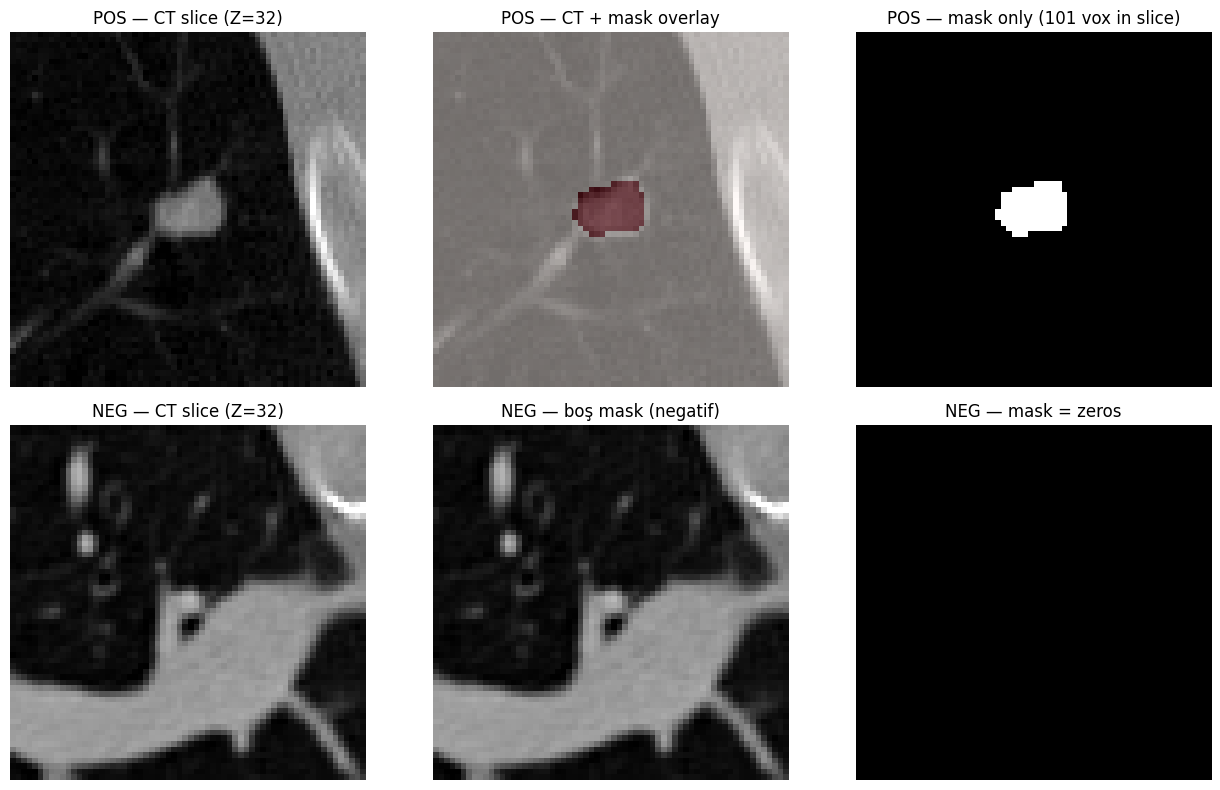


🔍 Beklenen:
  POZ overlay: kırmızı mask CT'de nodüle binmeli
  NEG CT:      sadece akciğer/doku, nodül görünmemeli


In [11]:
# Train set'ten bir pozitif (malign + mask) ve bir negatif bul
pos_with_mask = splits['train'][
    (splits['train']['is_nodule'] == 1) &
    (splits['train']['malignancy_label'] == 1) &
    (splits['train']['has_mask'] == True)
]
neg_samples = splits['train'][splits['train']['is_nodule'] == 0]

if len(pos_with_mask) == 0:
    print('⚠️ Mask\'li malign pozitif bulunamadı, herhangi bir pozitifle dene')
    pos_with_mask = splits['train'][splits['train']['is_nodule'] == 1]

pos_idx_in_train = pos_with_mask.index[0]
neg_idx_in_train = neg_samples.index[0]

# Augmentation'sız temiz versiyon için training=False ile geçici Dataset
viz_ds = LUNA16NoduleDataset(
    samples_df=splits['train'],
    npz_path_map=npz_path_map,
    masks_h5_path=MASKS_H5,
    patch_size=PATCH_SIZE,
    training=False, augment=False,
    hu_clip=HU_CLIP,
)

pos_s = viz_ds[pos_idx_in_train]
neg_s = viz_ds[neg_idx_in_train]

print(f'POZİTİF: {pos_s["seriesuid"][:30]}...')
print(f'  detection={pos_s["detection"]}, malignancy={pos_s["malignancy"]}, '
      f'seg_loss_mask={pos_s["seg_loss_mask"]}, mask_voxel={int(pos_s["mask"].sum())}')
print(f'NEGATİF: {neg_s["seriesuid"][:30]}...')
print(f'  detection={neg_s["detection"]}, malignancy={neg_s["malignancy"]}, '
      f'seg_loss_mask={neg_s["seg_loss_mask"]}, mask_voxel={int(neg_s["mask"].sum())}')

# Görselleştir: orta axial slice
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# Pozitif
p_patch = pos_s['patch'][0].numpy()  # (Z, Y, X)
p_mask = pos_s['mask'][0].numpy()
z_mid = PATCH_SIZE[0] // 2

axes[0, 0].imshow(p_patch[z_mid], cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f'POS — CT slice (Z={z_mid})')
axes[0, 0].axis('off')

axes[0, 1].imshow(p_patch[z_mid], cmap='gray', vmin=0, vmax=1)
axes[0, 1].imshow(p_mask[z_mid], cmap='Reds', alpha=0.45)
axes[0, 1].set_title(f'POS — CT + mask overlay')
axes[0, 1].axis('off')

axes[0, 2].imshow(p_mask[z_mid], cmap='gray')
axes[0, 2].set_title(f'POS — mask only ({int(p_mask[z_mid].sum())} vox in slice)')
axes[0, 2].axis('off')

# Negatif
n_patch = neg_s['patch'][0].numpy()
n_mask = neg_s['mask'][0].numpy()

axes[1, 0].imshow(n_patch[z_mid], cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'NEG — CT slice (Z={z_mid})')
axes[1, 0].axis('off')

axes[1, 1].imshow(n_patch[z_mid], cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title(f'NEG — boş mask (negatif)')
axes[1, 1].axis('off')

axes[1, 2].imshow(n_mask[z_mid], cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title(f'NEG — mask = zeros')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print('\n🔍 Beklenen:')
print('  POZ overlay: kırmızı mask CT\'de nodüle binmeli')
print('  NEG CT:      sadece akciğer/doku, nodül görünmemeli')

## 12. Hız testi

Drive'dan NPZ okuma + patch extraction hızı. Epoch süresi tahmini için kritik. Hedef: en az 5 sample/sec (yoksa training'de I/O bottleneck olur).

In [13]:
# Hız testi — Drive I/O dirençli versiyon

from google.colab import drive as gdrive

def remount_drive_if_needed():
    """Drive ölü mü kontrol et, öyleyse force remount."""
    try:
        os.listdir('/content/drive/MyDrive')
        return True
    except OSError:
        print('  ⚠️ Drive bağlantısı koptu, remount...')
        try:
            gdrive.mount('/content/drive', force_remount=True)
            time.sleep(3)
            return True
        except Exception as e:
            print(f'  ❌ Remount başarısız: {e}')
            return False

N_TRIALS = 15  # 30 yerine 15 (Drive sınırlamasını az yorsun diye)
test_indices = np.random.choice(len(train_ds), size=N_TRIALS, replace=False)
durations = []
failures = 0

print(f'Speed test: {N_TRIALS} sample (Drive I/O dirençli)...')
for i in tqdm(test_indices, desc='Loading'):
    t_start = time.time()
    for attempt in range(3):
        try:
            _ = train_ds[i]
            durations.append(time.time() - t_start)
            break
        except OSError as e:
            if e.errno in (5, 107):
                if not remount_drive_if_needed():
                    print(f'  Sample {i} skip (drive ölü)')
                    failures += 1
                    break
                # remount sonrası retry
            else:
                print(f'  Sample {i} OSError: {e}')
                failures += 1
                break
        except Exception as e:
            print(f'  Sample {i} hata: {type(e).__name__}: {e}')
            failures += 1
            break
    else:
        # 3 retry de başarısız
        failures += 1

if durations:
    rate = len(durations) / sum(durations)
    avg_sec = sum(durations) / len(durations)
    print(f'\n📊 SONUÇ:')
    print(f'  Başarılı:  {len(durations)}/{N_TRIALS}')
    print(f'  Başarısız: {failures}')
    print(f'  Ortalama:  {avg_sec:.2f} sec/sample → {rate:.2f} sample/sec')

    print(f'\nEpoch süresi tahmini (single worker, batch=1):')
    for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
        eta = len(ds) / rate
        print(f'  {name}: {len(ds)} sample → {eta/60:.1f} dakika '
              f'(batch=8, num_workers=4 ile ~{eta/60/4:.1f} dk)')

    if rate < 2:
        print(f'\n⚠️ ÇOK YAVAŞ ({rate:.1f} sample/sec).')
        print(f'   Drive I/O bottleneck. Notebook 4\'te şunları yapmamız gerekecek:')
        print(f'   • num_workers=4-8 paralel yükleme')
        print(f'   • Patch\'leri ön-hesapla → tek H5\'e koy (50+ sample/sec)')
        print(f'   • Veya scan-level caching (aynı NPZ\'den birden çok patch çek)')
    elif rate < 5:
        print(f'\n💡 Marjinal ({rate:.1f} sample/sec).')
        print(f'   num_workers=4 ile yeterli olabilir, ama patch ön-hesaplama daha güvenli.')
    else:
        print(f'\n✅ İyi ({rate:.1f} sample/sec). num_workers=4 ile çok rahat olur.')
else:
    print(f'\n❌ Hiç başarılı okuma olmadı. Drive ciddi bozulmuş.')
    print(f'   Runtime → Disconnect and delete runtime, sonra yeniden bağlan.')

Speed test: 15 sample (Drive I/O dirençli)...


Loading:   0%|          | 0/15 [00:00<?, ?it/s]


📊 SONUÇ:
  Başarılı:  15/15
  Başarısız: 0
  Ortalama:  4.41 sec/sample → 0.23 sample/sec

Epoch süresi tahmini (single worker, batch=1):
  train: 3480 sample → 255.7 dakika (batch=8, num_workers=4 ile ~63.9 dk)
  val: 400 sample → 29.4 dakika (batch=8, num_workers=4 ile ~7.3 dk)
  test: 520 sample → 38.2 dakika (batch=8, num_workers=4 ile ~9.6 dk)

⚠️ ÇOK YAVAŞ (0.2 sample/sec).
   Drive I/O bottleneck. Notebook 4'te şunları yapmamız gerekecek:
   • num_workers=4-8 paralel yükleme
   • Patch'leri ön-hesapla → tek H5'e koy (50+ sample/sec)
   • Veya scan-level caching (aynı NPZ'den birden çok patch çek)


## 13. DataLoader smoke test

Batch oluşturma, multi-worker pickling, GPU transfer çalışıyor mu?

In [14]:
# Single-worker test (Colab Drive I/O için multi-worker bazen sorunlu)
loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

print('Bir batch çekiyorum...')
t0 = time.time()
batch = next(iter(loader))
dt = time.time() - t0
print(f'  Süre: {dt:.2f}s')
print(f'\nBatch içeriği:')
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k:>15s}: shape={tuple(v.shape)}, dtype={v.dtype}')
    else:
        print(f'  {k:>15s}: {type(v).__name__}, len={len(v)}')

print(f'\n  Batch det:   {batch["detection"].tolist()}')
print(f'  Batch mal:   {batch["malignancy"].tolist()}')
print(f'  Batch segm:  {batch["seg_loss_mask"].tolist()}')

# Cleanup
del loader

Bir batch çekiyorum...
  Süre: 13.23s

Batch içeriği:
            patch: shape=(4, 1, 64, 64, 64), dtype=torch.float32
             mask: shape=(4, 1, 64, 64, 64), dtype=torch.float32
        detection: shape=(4,), dtype=torch.int64
       malignancy: shape=(4,), dtype=torch.int64
    seg_loss_mask: shape=(4,), dtype=torch.float32
        seriesuid: list, len=4

  Batch det:   [1, 1, 0, 0]
  Batch mal:   [1, -1, -1, -1]
  Batch segm:  [1.0, 1.0, 0.0, 0.0]


## 14. Özet ve sıradaki adım

In [15]:
print('=' * 60)
print('NOTEBOOK 2 — ÖZET')
print('=' * 60)
print(f'\nÇıktı dosyalar:')
print(f'  📄 {TRAIN_CSV}')
print(f'  📄 {VAL_CSV}')
print(f'  📄 {TEST_CSV}')
print(f'  📄 {SPLIT_META}')
print(f'\nDataset class: LUNA16NoduleDataset (bu notebook\'ta tanımlı)')
print(f'  Notebook 4\'te `from <bu_notebook_kodu> import LUNA16NoduleDataset` ile alacağız')
print(f'  ya da class\'ı doğrudan kopyalayacağız.')
print(f'\nSıradaki adım: Notebook 3 — Multi-task model mimarisi')
print(f'  • Pretrained ViT-L encoder yükle (DAPT epoch 3 ckpt)')
print(f'  • 3 head: detection (binary), malignancy (binary), segmentation (decoder)')
print(f'  • Forward pass smoke test, parameter count, memory profile')

NOTEBOOK 2 — ÖZET

Çıktı dosyalar:
  📄 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/train_samples.csv
  📄 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/val_samples.csv
  📄 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/test_samples.csv
  📄 /content/drive/MyDrive/bitirme/Finetune_Labels/splits/split_meta.json

Dataset class: LUNA16NoduleDataset (bu notebook'ta tanımlı)
  Notebook 4'te `from <bu_notebook_kodu> import LUNA16NoduleDataset` ile alacağız
  ya da class'ı doğrudan kopyalayacağız.

Sıradaki adım: Notebook 3 — Multi-task model mimarisi
  • Pretrained ViT-L encoder yükle (DAPT epoch 3 ckpt)
  • 3 head: detection (binary), malignancy (binary), segmentation (decoder)
  • Forward pass smoke test, parameter count, memory profile
